In [ ]:
import wandb
from glob import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Results for PPO, PD Control and Baseline

In [1]:
mean = {"baseline": [], "pd": [], "ppo": [], "ppo_ra10000": [], "ppo_ra100000": []}
std = {"baseline": [], "pd": [], "ppo": [], "ppo_ra10000": [], "ppo_ra100000": []}
ra = [10000, 100000, 1000000, 5000000]


# read from csv
for method in ["baseline", "pd", "ppo", "ppo_ra10000", "ppo_ra100000"]:
    for r in ra:
        path = f"res/{method}_ra{r}.csv"
        try:
            df = pandas.read_csv(path)

            # mean per episode
            df = df.groupby('episode').mean()

            mean[method].append(df["nusselt"].min())
            std[method].append(df["nusselt"].std())
        except Exception as e:
            mean[method].append(0)
            std[method].append(0)

# compute percentage
mean_percent = {"baseline": [], "pd": [], "ppo": [], "ppo_ra10000": [], "ppo_ra100000": []}
std_percent = {"baseline": [], "pd": [], "ppo": [], "ppo_ra10000": [], "ppo_ra100000": []}
for idx in range(len(mean["baseline"])):
    for method in ["baseline", "pd", "ppo", "ppo_ra10000", "ppo_ra100000"]:
        b = mean["baseline"][idx]
        mean_percent[method].append(100 - (100 * mean[method][idx] / b))
        std_percent[method].append(100 * std[method][idx] / b)


ZeroDivisionError: division by zero

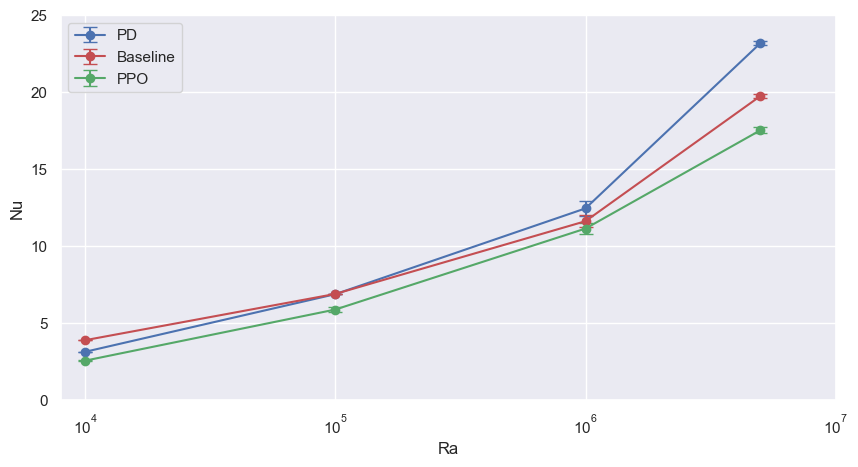

In [ ]:

# plot
plt.figure(figsize=(10, 5))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(0, 25)
#plt.yscale("log")
plt.ylabel("Nu")

# plot data
plt.errorbar(ra, mean["pd"], std["pd"], linestyle="-", marker='o', color='b', capsize=5, label="PD")
plt.errorbar(ra, mean["baseline"], std["baseline"], linestyle="-", marker='o', color='r', capsize=5, label="Baseline")
plt.errorbar(ra, mean["ppo"], std["ppo"], linestyle="-", marker='o', color='g', capsize=5, label="PPO")


plt.legend()
plt.show()

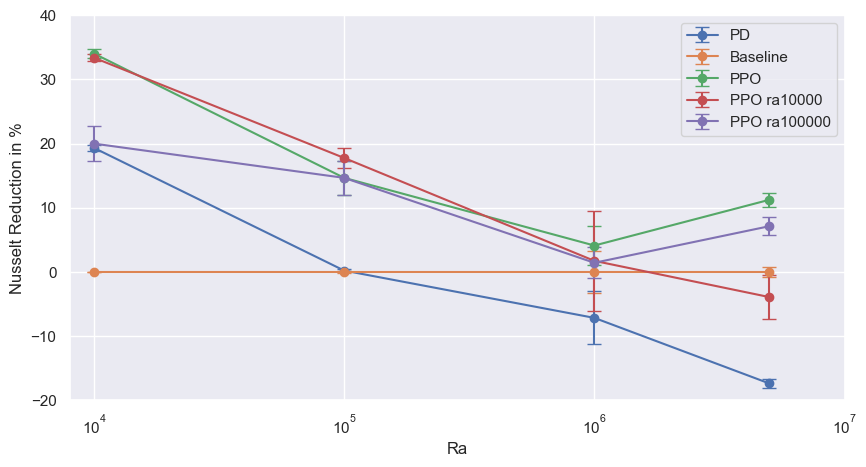

In [ ]:
# plot
plt.figure(figsize=(10, 5))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(-20, 40)
plt.ylabel("Nusselt Reduction in %")

# plot data
plt.errorbar(ra, mean_percent["pd"], std_percent["pd"], linestyle="-", marker='o', capsize=5, label="PD")
plt.errorbar(ra, mean_percent["baseline"], std_percent["baseline"], linestyle="-", marker='o', capsize=5, label="Baseline")
plt.errorbar(ra, mean_percent["ppo"], std_percent["ppo"], linestyle="-", marker='o', capsize=5, label="PPO")


plt.legend()
plt.show()

In [ ]:
# plot
plt.figure(figsize=(10, 5))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(-20, 40)
plt.ylabel("Nusselt Reduction in %")

# plot data
plt.errorbar(ra, mean_percent["ppo"], std_percent["ppo"], linestyle="-", marker='o', capsize=5, label="PPO")
plt.errorbar(ra, mean_percent["ppo_ra10000"], std_percent["ppo_ra10000"], linestyle="-", marker='o', capsize=5, label="PPO ra10000")
plt.errorbar(ra, mean_percent["ppo_ra100000"], std_percent["ppo_ra100000"], linestyle="-", marker='o', capsize=5, label="PPO ra100000")


plt.legend()
plt.show()